<a href="https://colab.research.google.com/github/vikassinngh123/AI-ML-Learning/blob/main/06-Deep-Learning/01-PyTorch/01-PyTorch-Basic-Models/03_mnist_classification_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
#For plots and visualization
import matplotlib.pyplot as plt
import seaborn as sns
#For data loading
from tensorflow.keras.datasets import mnist

from sklearn.model_selection import train_test_split

import torch
from torch import nn

In [2]:
(X,y),(_,_) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
X.shape,y.shape

((60000, 28, 28), (60000,))

In [4]:
X=X.reshape(60000,784)

In [5]:
X=X/255     #Dividing it by 255 gives values between 0-1(why we need values b/w 0-1 as if values are to high and lr is also high due to which the model make massive , violent updates to its weights during the first few epochs. which makes weights and the results go to negative and then ReLU converts it to 0 and gradient becomes zero )

In [6]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
#Device agnostice code
device="cuda" if torch.cuda.is_available() else "cpu"

In [8]:
X_train=torch.tensor(X_train,dtype=torch.float32)
X_test=torch.tensor(X_test,dtype=torch.float32)
y_train=torch.tensor(y_train,dtype=torch.long)
y_test=torch.tensor(y_test,dtype=torch.long)

In [9]:
X_train,X_test=X_train.to(device),X_test.to(device)
y_train,y_test=y_train.to(device),y_test.to(device)

In [10]:
class numbermodel_ReLU(nn.Module):
  def __init__(self,input_features,hidden_features,output_features):
    '''Args:
            input_features(int):Number of input features
            hidden_features(int):Number of hidden features
            output_features(int):Number of output features
    '''
    super().__init__()
    self.sequential=nn.Sequential(
                                  nn.Linear(input_features,hidden_features),
                                  nn.ReLU(),
                                  nn.Dropout(0.2),                              #This will randomly "turn off" some neurons during training which will forces the model to learn robust features rather than just memorizing the data
                                  nn.Linear(hidden_features,hidden_features),
                                  nn.ReLU(),
                                  nn.Dropout(0.2),
                                  nn.Linear(hidden_features,hidden_features),
                                  nn.ReLU(),
                                  nn.Dropout(0.2),
                                  nn.Linear(hidden_features,output_features)
                                 )

  def forward(self,x):
    return self.sequential(x)

model=numbermodel_ReLU(784,128,10).to(device)
model

numbermodel_ReLU(
  (sequential): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [11]:
loss_fn=nn.CrossEntropyLoss()

optimizer=torch.optim.Adam(params=model.parameters(),lr=0.001)

def accuracy_fn(y_true,y_pred):
  correct=torch.eq(y_true,y_pred).sum().item()
  acc=correct/len(y_pred)
  return acc*100

In [12]:
epochs=1000

#saving These values for every 100 epochs for loss graph and accuracy graph
ecoch_count=[]
train_loss_val=[]
train_acc_val=[]
test_loss_val=[]
test_acc_val=[]

for epochs in range(epochs):
  model.train()

  y_logits=model(X_train)
  y_pred=torch.argmax(torch.softmax(y_logits,dim=1),dim=1)

  loss=loss_fn(y_logits,y_train)
  train_accuracy=accuracy_fn(y_train,y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model.eval()
  with torch.inference_mode():
    test_logits=model(X_test)
    test_pred=torch.argmax(torch.softmax(test_logits,dim=1),dim=1)

    test_loss=loss_fn(test_logits,y_test)
    test_accuracy=accuracy_fn(y_test,test_pred)

  if epochs%100==0 or epochs==999:
    print(f"Epochs:{epochs} | Train_Loss:{loss: .2f} | Train_Accuracy:{train_accuracy: .2f} | Test_Loss:{test_loss: .2f} | Test_Accuracy:{test_accuracy: .2f}")

    ecoch_count.append(epochs)

    train_loss_val.append(loss.item())
    train_acc_val.append(train_accuracy)
    test_loss_val.append(test_loss.item())
    test_acc_val.append(test_accuracy)

Epochs:0 | Train_Loss: 2.30 | Train_Accuracy: 9.86 | Test_Loss: 2.29 | Test_Accuracy: 19.83
Epochs:100 | Train_Loss: 0.23 | Train_Accuracy: 93.28 | Test_Loss: 0.18 | Test_Accuracy: 94.58
Epochs:200 | Train_Loss: 0.11 | Train_Accuracy: 96.83 | Test_Loss: 0.10 | Test_Accuracy: 96.92
Epochs:300 | Train_Loss: 0.06 | Train_Accuracy: 98.12 | Test_Loss: 0.08 | Test_Accuracy: 97.58
Epochs:400 | Train_Loss: 0.04 | Train_Accuracy: 98.75 | Test_Loss: 0.08 | Test_Accuracy: 97.82
Epochs:500 | Train_Loss: 0.03 | Train_Accuracy: 99.21 | Test_Loss: 0.08 | Test_Accuracy: 97.92
Epochs:600 | Train_Loss: 0.02 | Train_Accuracy: 99.39 | Test_Loss: 0.08 | Test_Accuracy: 97.95
Epochs:700 | Train_Loss: 0.01 | Train_Accuracy: 99.56 | Test_Loss: 0.09 | Test_Accuracy: 97.96
Epochs:800 | Train_Loss: 0.01 | Train_Accuracy: 99.64 | Test_Loss: 0.09 | Test_Accuracy: 97.93
Epochs:900 | Train_Loss: 0.01 | Train_Accuracy: 99.74 | Test_Loss: 0.09 | Test_Accuracy: 97.95
Epochs:999 | Train_Loss: 0.01 | Train_Accuracy: 99.78

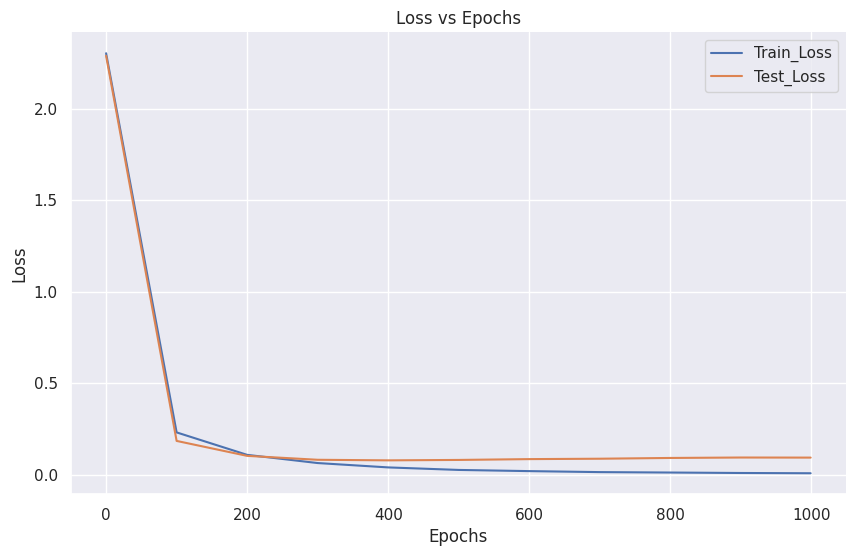

In [13]:
#Ploting the Loss v/s Epochs graph

plt.figure(figsize=(10,6))
sns.set_theme(style="darkgrid")

plt.title("Loss vs Epochs")
sns.lineplot(x=ecoch_count,y=train_loss_val,label="Train_Loss")
sns.lineplot(x=ecoch_count,y=test_loss_val,label="Test_Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(bbox_to_anchor=(1,1))

sns.despine()
plt.show()

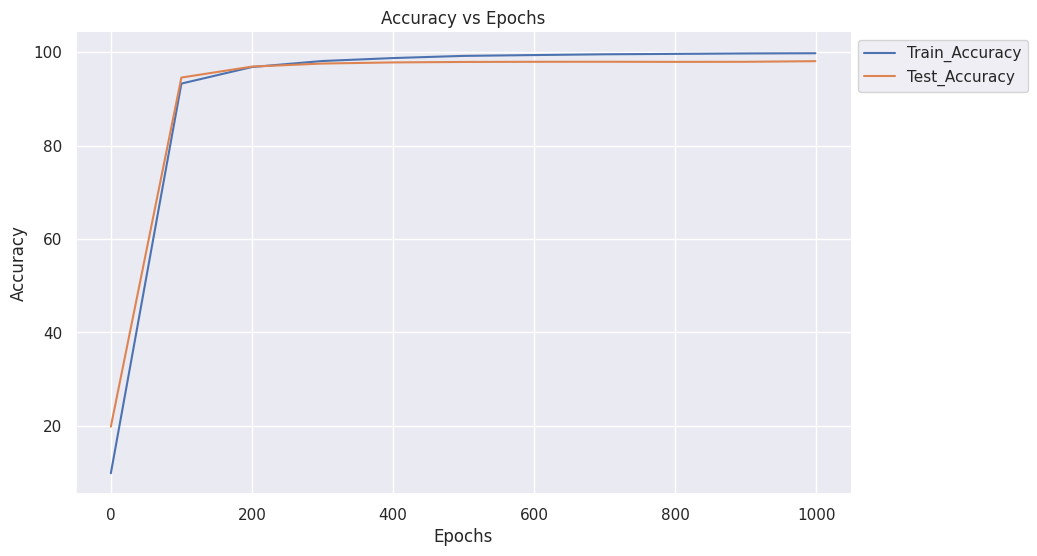

In [14]:
#Ploting Accuracy v/s Epochs graph

plt.figure(figsize=(10,6))
sns.set_theme(style="darkgrid")

plt.title("Accuracy vs Epochs")
sns.lineplot(x=ecoch_count,y=train_acc_val,label="Train_Accuracy")
sns.lineplot(x=ecoch_count,y=test_acc_val,label="Test_Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(bbox_to_anchor=(1,1))

sns.despine()
plt.show()

In [15]:
test_pred[:10],y_test[:10]

(tensor([7, 3, 8, 9, 3, 9, 7, 7, 5, 4], device='cuda:0'),
 tensor([7, 3, 8, 9, 3, 9, 7, 7, 5, 4], device='cuda:0'))

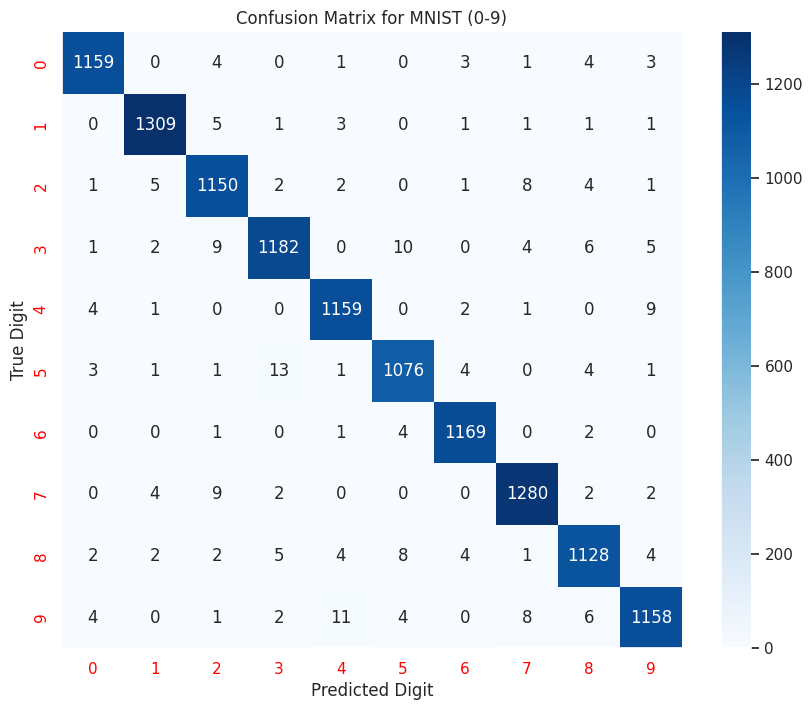

In [16]:
from sklearn.metrics import confusion_matrix

#Moving tensors to CPU and converting it to NumPy arrays
y_test_cpu = y_test.cpu().numpy()
test_pred_cpu = test_pred.cpu().numpy()

#Calculating the confusion matrix with the help of sklearn
cm = confusion_matrix(y_test_cpu, test_pred_cpu)

#Plot it using heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',                  #annot=True this parameter will write the exact count of images in each box making it easier to spot model's weaknesses
            xticklabels=range(10), yticklabels=range(10))

plt.title('Confusion Matrix for MNIST (0-9)')
plt.xlabel('Predicted Digit')
plt.ylabel('True Digit')

plt.xticks(color='red')
plt.yticks(color='red')

sns.despine()
plt.show()

In [17]:
#Saving the models state dict
torch.save(model.state_dict(), "03_mnist_model_weights.pth")